In [6]:
from deap import tools, creator, base, algorithms, benchmarks
import pymop
from math import factorial
from numpy import random
from meamt_core import generate_dtlz1_front_random, calculate_igd_plus
import numpy
from deap.benchmarks.tools import hypervolume
import numpy as np

PROBLEM = "dtlz1"
NOBJ = 4
K = 5
NDIM = NOBJ + K - 1
P = 12
BOUND_LOW, BOUND_UP = 0.0, 1.0
pareto_real = generate_dtlz1_front_random(NOBJ, 1000)

In [7]:
MU = 800
NGEN = 600
CXPB = 1.0
MUTPB = 1.0

ref_points_hv = [1.1] * NOBJ
ref_points = tools.uniform_reference_points(NOBJ, P)


In [8]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,) * NOBJ)
creator.create("Individual", list, fitness=creator.FitnessMin)

def uniform(low, up, size=None):
    try:
        return [random.uniform(a, b) for a, b in zip(low, up)]
    except TypeError:
        return [random.uniform(a, b) for a, b in zip([low] * size, [up] * size)]

toolbox = base.Toolbox()
toolbox.register("attr_float", uniform, BOUND_LOW, BOUND_UP, NDIM)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", benchmarks.dtlz1, obj=NOBJ)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=30.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=20.0, indpb=1.0/NDIM)
toolbox.register("select", tools.selNSGA3, ref_points=ref_points)

c:\Users\luise\AppData\Local\Programs\Python\Python312\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\luise\AppData\Local\Programs\Python\Python312\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [9]:
def main(seed=None):
    random.seed(seed)

    # Initialize statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean, axis=0)
    stats.register("std", numpy.std, axis=0)
    stats.register("min", numpy.min, axis=0)
    stats.register("max", numpy.max, axis=0)

    logbook = tools.Logbook()
    logbook.header = "gen", "evals", "std", "min", "avg", "max", "hypervolume", "igd_plus"

    pop = toolbox.population(n=MU)

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Compile statistics about the population
    record = stats.compile(pop)
    logbook.record(gen=0, evals=len(invalid_ind), **record)
    print(logbook.stream)

    # Begin the generational process
    for gen in range(1, NGEN):
        offspring = algorithms.varAnd(pop, toolbox, CXPB, MUTPB)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Select the next generation population from parents and offspring
        pop = toolbox.select(pop + offspring, MU)

        # Compile statistics about the new population
        record = stats.compile(pop)
        pop_comp = pop[:(int)(MU/(1 << NOBJ))]
        hv_val = hypervolume(pop_comp, ref_points_hv)
        approx_front = np.array([ind.fitness.values for ind in pop])
        approx_front_comp = approx_front[:(int)(MU/(1 << NOBJ))]
        igd_plus_val = calculate_igd_plus(pareto_real, approx_front_comp)
        logbook.record(gen=gen, evals=len(invalid_ind), hypervolume=hv_val,igd_plus=igd_plus_val, **record)
        print(logbook.stream)

    return pop, logbook

In [10]:
pop, logbook = main()

gen	evals	std                                              	min                                          	avg                                                  	max                                                  	hypervolume	igd_plus
0  	800  	[41.53362906 42.89716682 67.13642365 95.68900521]	[0.00346067 0.0094347  0.01153579 0.86784106]	[ 33.24622933  32.87088834  68.49675925 138.5763212 ]	[298.59581991 285.02528428 390.50120064 437.05607484]	           	        
1  	800  	[46.9344031  45.84760356 70.43403813 90.706946  ]	[0.00346067 0.00086681 0.01153579 0.27247906]	[ 32.08975316  30.23470063  61.292704   109.19958539]	[301.68767171 301.09327572 415.18147943 426.11364973]	0          	17.031  
2  	800  	[55.65597767 47.45639543 77.76995983 80.64719883]	[1.39082422e-04 5.43053589e-04 9.70442270e-03 2.72479058e-01]	[39.97123582 29.70092036 67.91936934 73.12052775]    	[301.68767171 395.45019628 416.55280283 475.93092847]	0          	17.031  
3  	800  	[58.98521123 48.58517813 72.394147

[0.9167881125774109, 0.997528448758546, 0.18713335393464822, 0.5000060722181505, 0.5000081743090117, 0.5000288532624779, 0.5000002125257234, 0.4999993265944491]
[0.9995960590595925, 0.6651329672847203, 0.9940960245710018, 0.5000238950193292, 0.5000111337290049, 0.4996147506403382, 0.4999997317168511, 0.4999968278205241]
[0.9159597692057325, 0.17581261053941113, 2.575134651189984e-05, 0.5000169998968532, 0.499997508761152, 0.5000161412010704, 0.5000050014464981, 0.4999982998259412]
[0.5915308554065742, 0.9981016195890049, 0.2825574794869534, 0.5000137007954772, 0.5000071721775217, 0.500011469971928, 0.5000081271738962, 0.4999976834660177]
[0.4110820101769177, 0.5796628218902794, 0.2772490740483531, 0.49998445045915413, 0.5000086306395137, 0.500018584282487, 0.5000005905335082, 0.49999557053418425]
[0.8350000703725777, 0.41197858187968406, 0.004624831211488212, 0.4999998884080922, 0.4999969916302271, 0.5000107408347477, 0.5000070974244072, 0.49998931422971077]
[0.5866007535373439, 0.1489

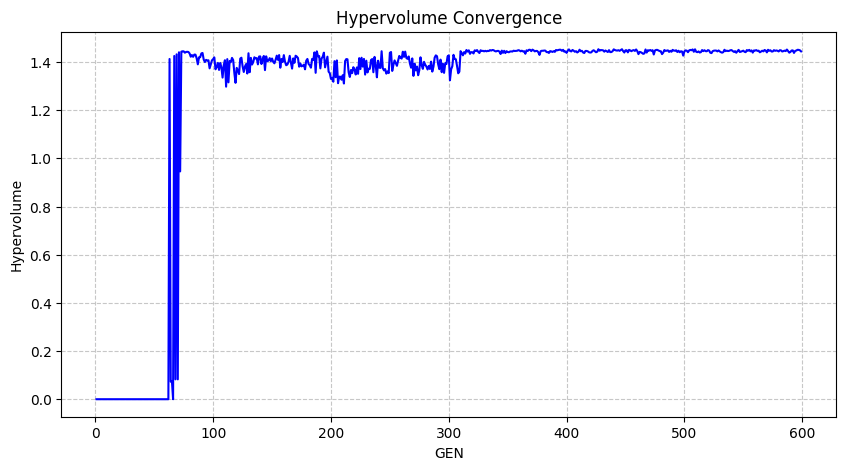

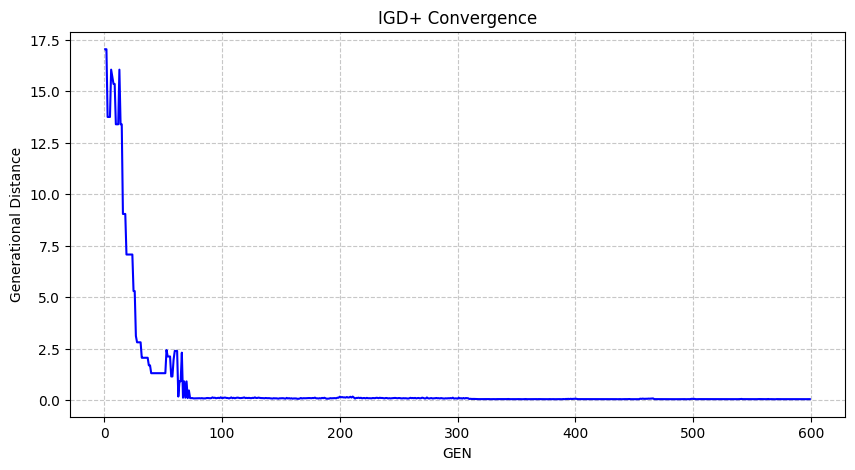

In [11]:
import matplotlib.pyplot as plt

for ind in pop:
   print(ind)

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()